## Notes for Sureksha:
- I created functions to load well files (a single horizontal file, randomly, with its corresponding Typewell file)
- I then analysed the datasets with .info(), .describe() etc
- plotted to visualise

## GR shape comparison — Typewell vs Horizontal well

This plots GR vs TVT (typewell) and GR vs MD (horizontal well) side by side, normalized
onto the same 0–1 axis just to visually check that the two GR curves look similar in shape.

<div style="background-color:#e6f4ea; border-left:5px solid #34a853; padding:10px; border-radius:4px;">
<b>Update:</b> I've started writing <code>process_well</code>, a function that takes one well's horizontal
and typewell data and processes them together. For each well, it slides a window of the horizontal
well's GR values across the typewell's GR curve, scores how well each position matches (cross-correlation),
and finds the best-matching TVT for each window. That matched TVT — plus a confidence/correlation score —
gets assigned to the center row of the window, as two new columns (<code>matched_TVT</code>, <code>matched_score</code>)
in the horizontal well's dataframe.

Still need to finish the <b>rolling window / feature engineering</b> part (local averages/trends over
nearby rows, to give the model some sense of sequence without needing a sequence model).

Once <code>process_well</code> is complete, we'll loop it over every well, and each processed well gets
concatenated together — so we end up with one big horizontal dataset (one row per point, across all wells)
to train the model (LightGBM) with.

🛎️ Ping me if still not clear, or if you want to propose a different way or additional step before this ;)
</div>

# 1. Dependencies 

In [1]:
# import all libraries and functions here ...
import pandas as pd 
import numpy as np 
import os
import glob
import random 
import matplotlib.pyplot as plt
from scipy.signal import correlate 
from tqdm.notebook import tqdm

# 2. Exploratory Data Analysis 

In [2]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

WINDOW = 25 # for cross correlation 
ROLLING_WINDOW = 30

In [3]:
# code to see all files in the data/ input directory 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [4]:
# check horizontal csv file 
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [5]:
# check typewell csv file 
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df 

In [6]:
# get matching typewell file 
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [7]:
h_df, ID , tw_df = get_matching_files()

In [8]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,12102.0,3022165.43,1081657.97,-9923.43,-10339.5,-10505.36,-10550.12,-10615.12,-10646.12,-10809.12,11922.76,NaN,11922.76,94d813a4
1,12103.0,3022165.43,1081657.97,-9924.43,-10339.5,-10505.36,-10550.12,-10615.12,-10646.12,-10809.12,11923.76,114.581866,11923.76,94d813a4
2,12104.0,3022165.43,1081657.97,-9925.43,-10339.5,-10505.36,-10550.12,-10615.12,-10646.12,-10809.12,11924.76,113.081630,11924.76,94d813a4
3,12105.0,3022165.43,1081657.97,-9926.43,-10339.5,-10505.36,-10550.12,-10615.12,-10646.12,-10809.12,11925.76,111.400515,11925.76,94d813a4
4,12106.0,3022165.43,1081657.97,-9927.43,-10339.5,-10505.36,-10550.12,-10615.12,-10646.12,-10809.12,11926.76,110.645077,11926.76,94d813a4


In [9]:
tw_df.head()

,TVT,GR,Geology
0,11910.45,126.01,NaN
1,11910.95,129.09,NaN
2,11911.45,131.77,NaN
3,11911.95,135.58,NaN
4,11912.45,137.45,NaN


In [10]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6591 entries, 0 to 6590
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         6591 non-null   float64
 1   X          6591 non-null   float64
 2   Y          6591 non-null   float64
 3   Z          6591 non-null   float64
 4   ANCC       6591 non-null   float64
 5   ASTNU      6591 non-null   float64
 6   ASTNL      6591 non-null   float64
 7   EGFDU      6591 non-null   float64
 8   EGFDL      6591 non-null   float64
 9   BUDA       6591 non-null   float64
 10  TVT        6591 non-null   float64
 11  GR         4837 non-null   float64
 12  TVT_input  1744 non-null   float64
 13  WELL_ID    6591 non-null   object 
dtypes: float64(13), object(1)
memory usage: 721.0+ KB


In [11]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,6591.000000,6.591000e+03,6.591000e+03,6591.000000,6591.000000,6591.000000,6591.000000,6591.000000,6591.000000,6591.000000,6591.000000,4837.000000,1744.000000
mean,15397.000000,3.020657e+06,1.084023e+06,-10532.777281,-10206.279426,-10372.139426,-10416.899426,-10481.899426,-10512.899426,-10675.899426,12665.326817,95.533172,12538.089455
std,1902.802144,1.003457e+03,1.572396e+03,128.079085,61.784533,61.784533,61.784533,61.784533,61.784533,61.784533,149.742917,16.859725,247.802048
min,12102.000000,3.018892e+06,1.081658e+06,-10655.590000,-10339.750000,-10505.610000,-10550.370000,-10615.370000,-10646.370000,-10809.370000,11922.760000,39.325339,11922.760000
25%,13749.500000,3.019794e+06,1.082615e+06,-10618.485000,-10253.500000,-10419.360000,-10464.120000,-10529.120000,-10560.120000,-10723.120000,12684.725000,83.193947,12394.635000
50%,15397.000000,3.020677e+06,1.084009e+06,-10560.020000,-10202.580000,-10368.440000,-10413.200000,-10478.200000,-10509.200000,-10672.200000,12715.500000,96.813112,12678.535000
75%,17044.500000,3.021550e+06,1.085397e+06,-10492.445000,-10157.865000,-10323.725000,-10368.485000,-10433.485000,-10464.485000,-10627.485000,12727.405000,107.931883,12721.610000
max,18692.000000,3.022166e+06,1.086774e+06,-9923.430000,-10111.680000,-10277.540000,-10322.300000,-10387.300000,-10418.300000,-10581.300000,12740.580000,222.928709,12740.530000


In [12]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927 entries, 0 to 1926
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1927 non-null   float64
 1   GR       1927 non-null   float64
 2   Geology  1070 non-null   object 
dtypes: float64(2), object(1)
memory usage: 45.3+ KB


In [13]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
1922    BUDA
1923    BUDA
1924    BUDA
1925    BUDA
1926    BUDA
Name: Geology, Length: 1927, dtype: object

In [14]:
# another well 
h_df_1, _, tw_df_1 = get_matching_files()

In [15]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10679.0,2904795.43,1031050.31,-8640.64,-8779.05,-9002.49,-9068.87,-9118.39,-9156.42,-9282.74,10624.09,118.385350,10624.09,87aa3730
1,10680.0,2904795.41,1031050.31,-8641.64,-8779.06,-9002.50,-9068.88,-9118.40,-9156.44,-9282.75,10625.07,125.533144,10625.07,87aa3730
2,10681.0,2904795.38,1031050.32,-8642.64,-8779.08,-9002.52,-9068.90,-9118.41,-9156.45,-9282.77,10626.06,107.649247,10626.06,87aa3730
3,10682.0,2904795.36,1031050.32,-8643.64,-8779.09,-9002.53,-9068.91,-9118.42,-9156.46,-9282.78,10627.05,94.304775,10627.05,87aa3730
4,10683.0,2904795.33,1031050.33,-8644.64,-8779.10,-9002.54,-9068.92,-9118.44,-9156.47,-9282.79,10628.04,87.747826,10628.04,87aa3730


In [16]:
h_df_1.shape

(7293, 14)

In [17]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7293 entries, 0 to 7292
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         7293 non-null   float64
 1   X          7293 non-null   float64
 2   Y          7293 non-null   float64
 3   Z          7293 non-null   float64
 4   ANCC       7293 non-null   float64
 5   ASTNU      7293 non-null   float64
 6   ASTNL      7293 non-null   float64
 7   EGFDU      7293 non-null   float64
 8   EGFDL      7293 non-null   float64
 9   BUDA       7293 non-null   float64
 10  TVT        7293 non-null   float64
 11  GR         5721 non-null   float64
 12  TVT_input  1686 non-null   float64
 13  WELL_ID    7293 non-null   object 
dtypes: float64(13), object(1)
memory usage: 797.8+ KB


In [18]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1510 non-null   float64
 1   GR       1510 non-null   float64
 2   Geology  1208 non-null   object 
dtypes: float64(2), object(1)
memory usage: 35.5+ KB


In [19]:
def plot_x_y(x, y, x_label , y_label, title):
    plt.figure(figsize = (20,8))
    plt.plot(x, y, linewidth = 0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha = 0.3)
    plt.show()

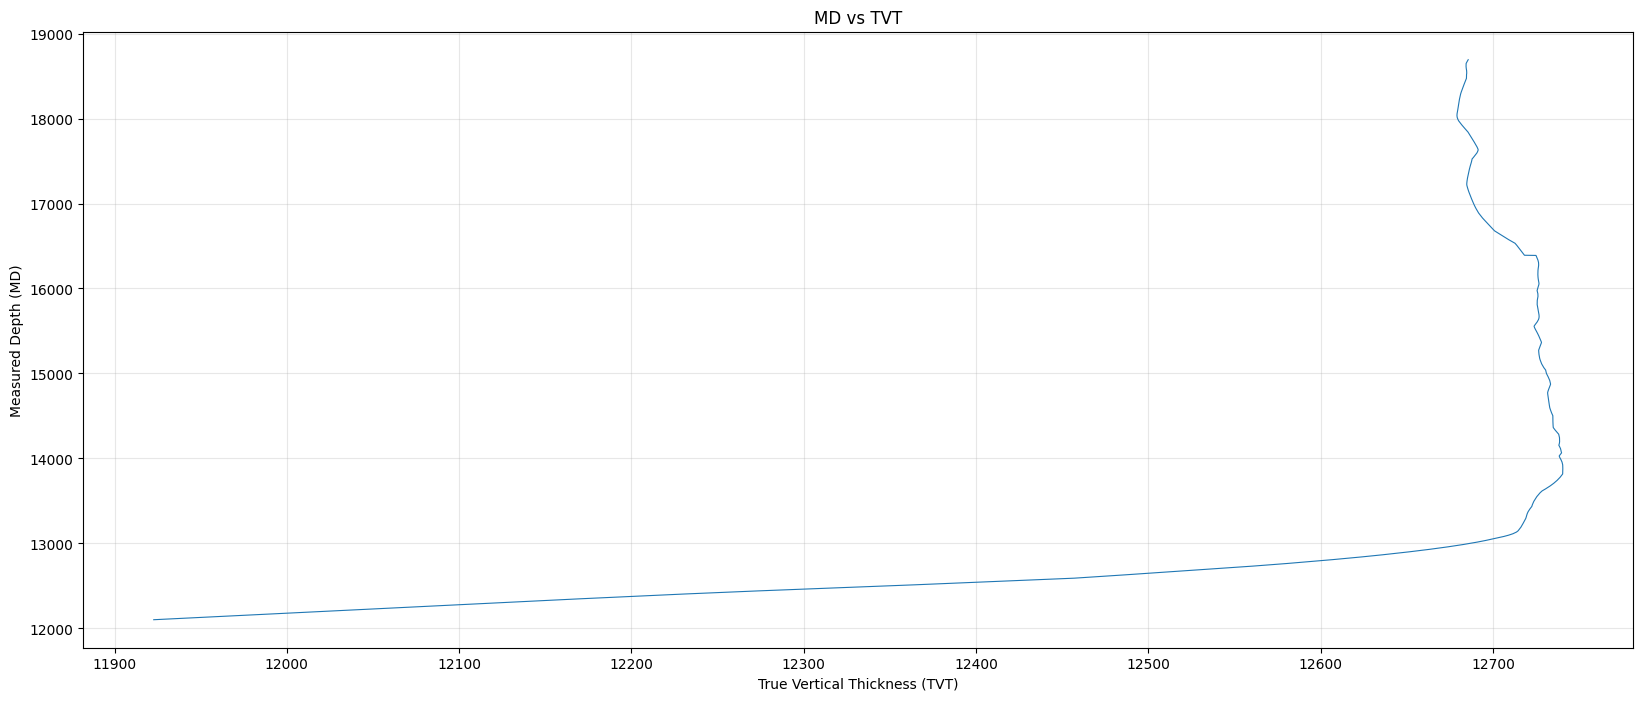

In [20]:
# MD against TVT 
# illustrates where the horizontal drilling starts (?)
plot_x_y(h_df['TVT'], h_df['MD'], "True Vertical Thickness (TVT)", "Measured Depth (MD)", "MD vs TVT")

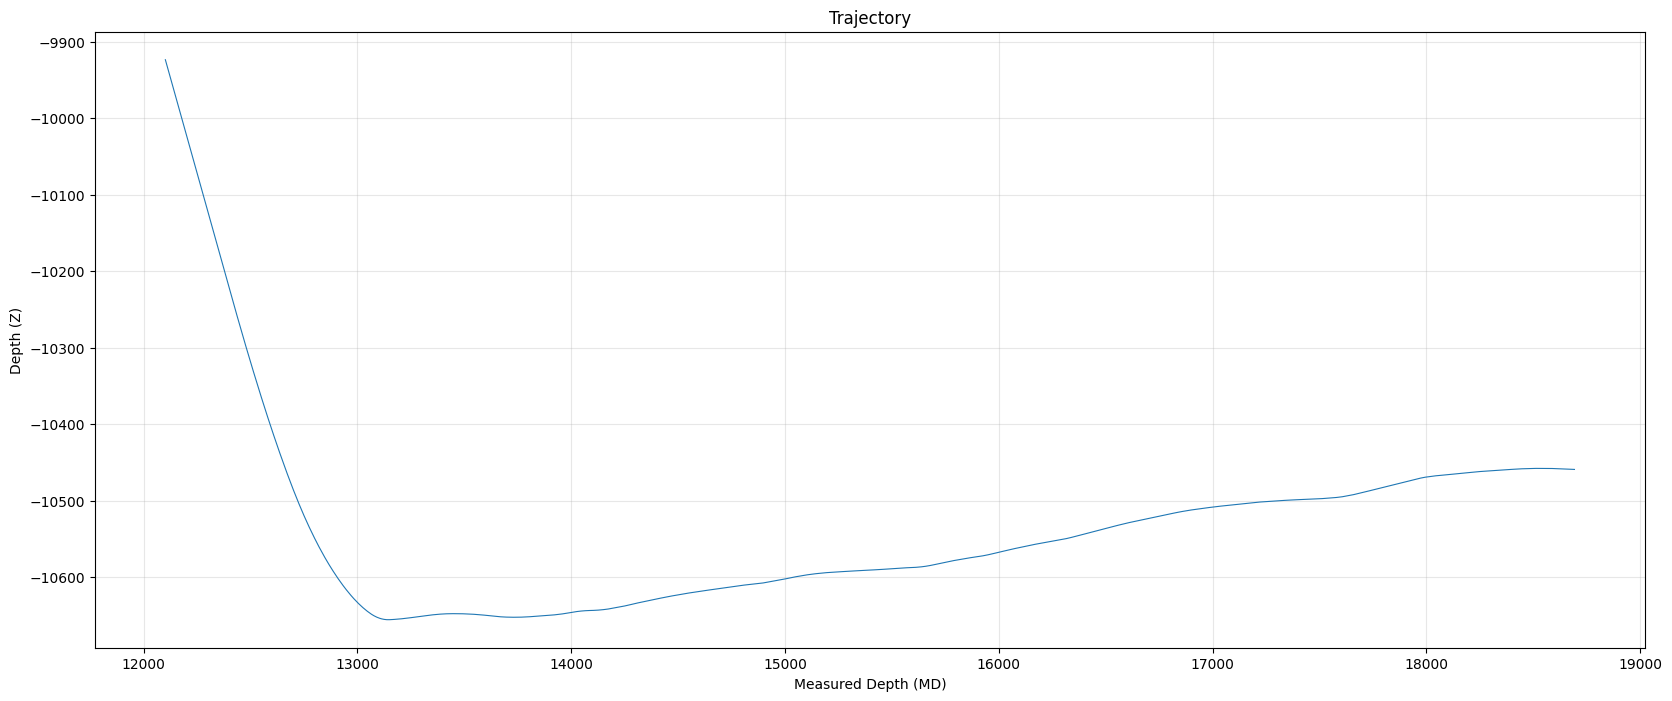

In [21]:
# y against x 
plot_x_y(h_df['MD'], h_df['Z'], "Measured Depth (MD)", "Depth (Z)", "Trajectory")

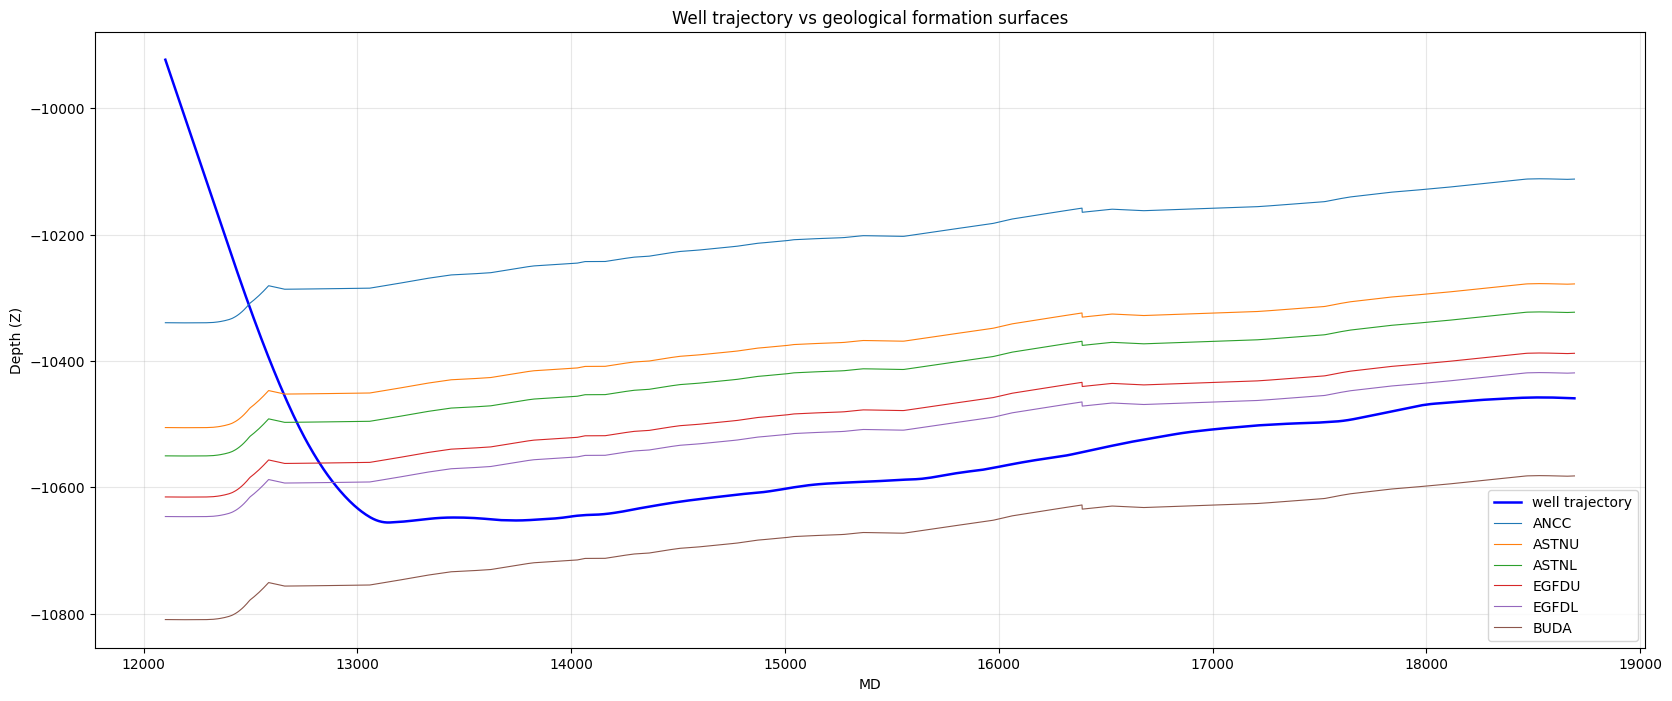

In [22]:
plt.figure(figsize=(20, 8))
plt.plot(h_df['MD'], h_df['Z'], linewidth=1.8, label='well trajectory', color='blue')
plt.plot(h_df['MD'], h_df['ANCC'], linewidth=0.8, label='ANCC')
plt.plot(h_df['MD'], h_df['ASTNU'], linewidth=0.8, label='ASTNU')
plt.plot(h_df['MD'], h_df['ASTNL'], linewidth=0.8, label='ASTNL')
plt.plot(h_df['MD'], h_df['EGFDU'], linewidth=0.8, label='EGFDU')
plt.plot(h_df['MD'], h_df['EGFDL'], linewidth=0.8, label='EGFDL')
plt.plot(h_df['MD'], h_df['BUDA'], linewidth=0.8, label='BUDA')
plt.xlabel("MD")
plt.ylabel("Depth (Z)")
plt.title("Well trajectory vs geological formation surfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

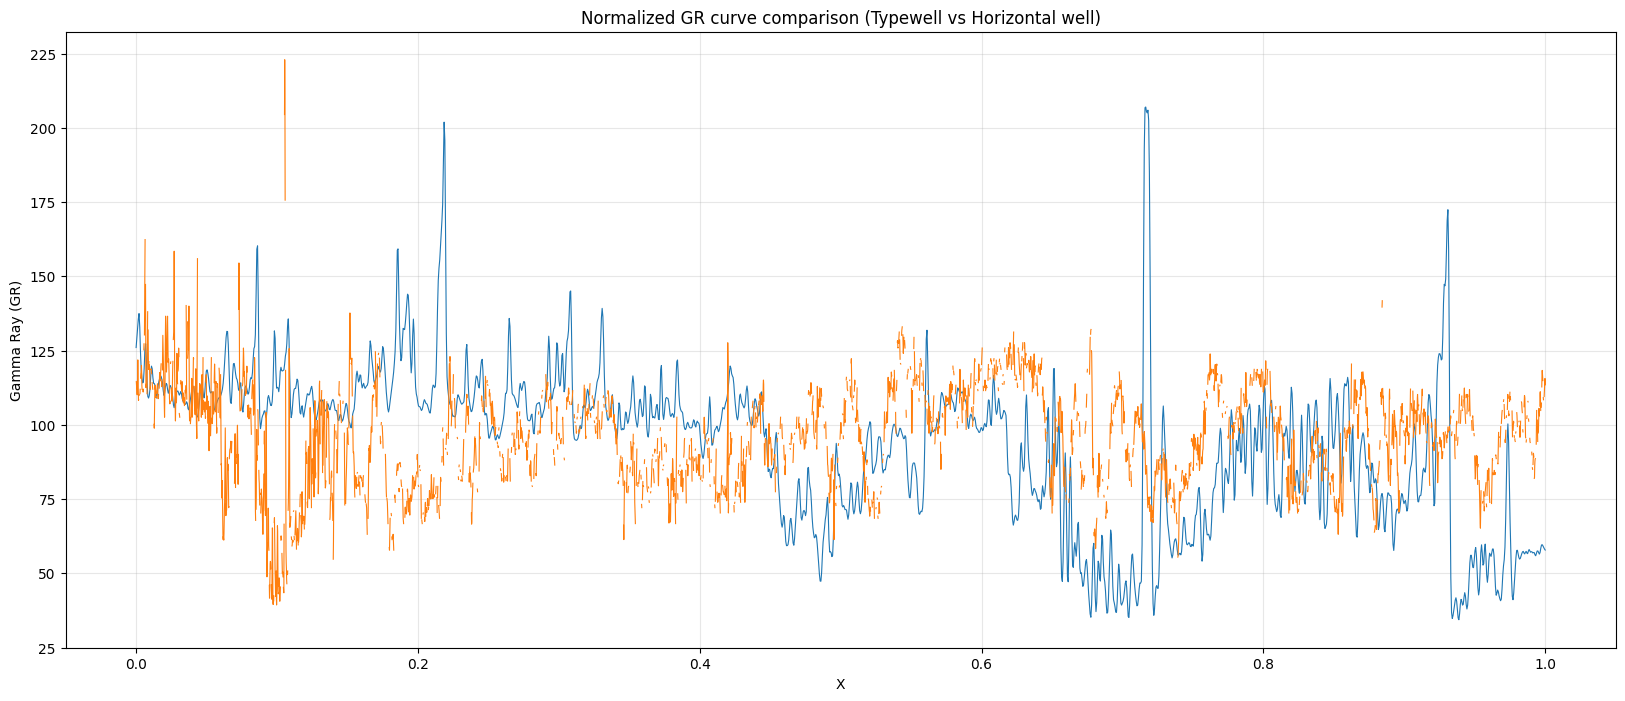

In [23]:
# Quick visual check: do the two GR curves have a similar shape/pattern?
# This does NOT find the actual TVT match — it's just eyeballing texture before
# building the real sliding-window correlation function.

# normalising for a cleaner look 
tw_norm = (tw_df['TVT']- tw_df['TVT'].min())/ (tw_df['TVT'].max() - tw_df['TVT'].min())
h_norm = (h_df['MD'] - h_df['MD'].min()) / (h_df['MD'].max() - h_df['MD'].min())

#plotting 
plt.figure(figsize = (20,8))
plt.plot(tw_norm, tw_df['GR'], linewidth = 0.8 , label = 'Typewell GR')
plt.plot(h_norm, h_df['GR'], linewidth = 0.8, label = 'Horizontal Well GR')
plt.xlabel("X")
plt.ylabel("Gamma Ray (GR)")
plt.title("Normalized GR curve comparison (Typewell vs Horizontal well)")
plt.grid(True, alpha = 0.3)
plt.show()


# 3. Data Proprocessing 

Before we can train anything, we need to turn each well's raw files into one clean table the model can actually learn from. Here's what we're doing for each well:

**Matching horizontal well points to the typewell.**
The horizontal well and typewell are two separate logs — they don't line up row by row, so we can't just merge them directly. Instead, we slide the horizontal well's GR curve across the typewell's GR curve to find where the patterns line up best (cross-correlation). Wherever we find a strong match, we grab the corresponding TVT from the typewell and attach it to that row, along with a score telling us how confident that match is.

**Adding a few engineered features.**
Since the data is sequential (each row depends a bit on the ones around it), we add some rolling-window features — basically local averages/trends over the last few rows — so the model gets a sense of what's happening nearby, not just at a single isolated point.

**Not bothering with missing values.**
There are NaNs scattered through the data, but we're not filling or dropping them — LightGBM handles missing values on its own during training, so it's one less thing to worry about.

**One exception: GR needs to be NaN-free just for the matching step.**
Cross-correlation breaks completely if there's even one NaN in the window, so we make a separate interpolated copy of GR purely to run the matching on. We don't touch the original GR column — that one keeps its real gaps and is what actually goes into the model.

In [24]:
# function to normalize arrays
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

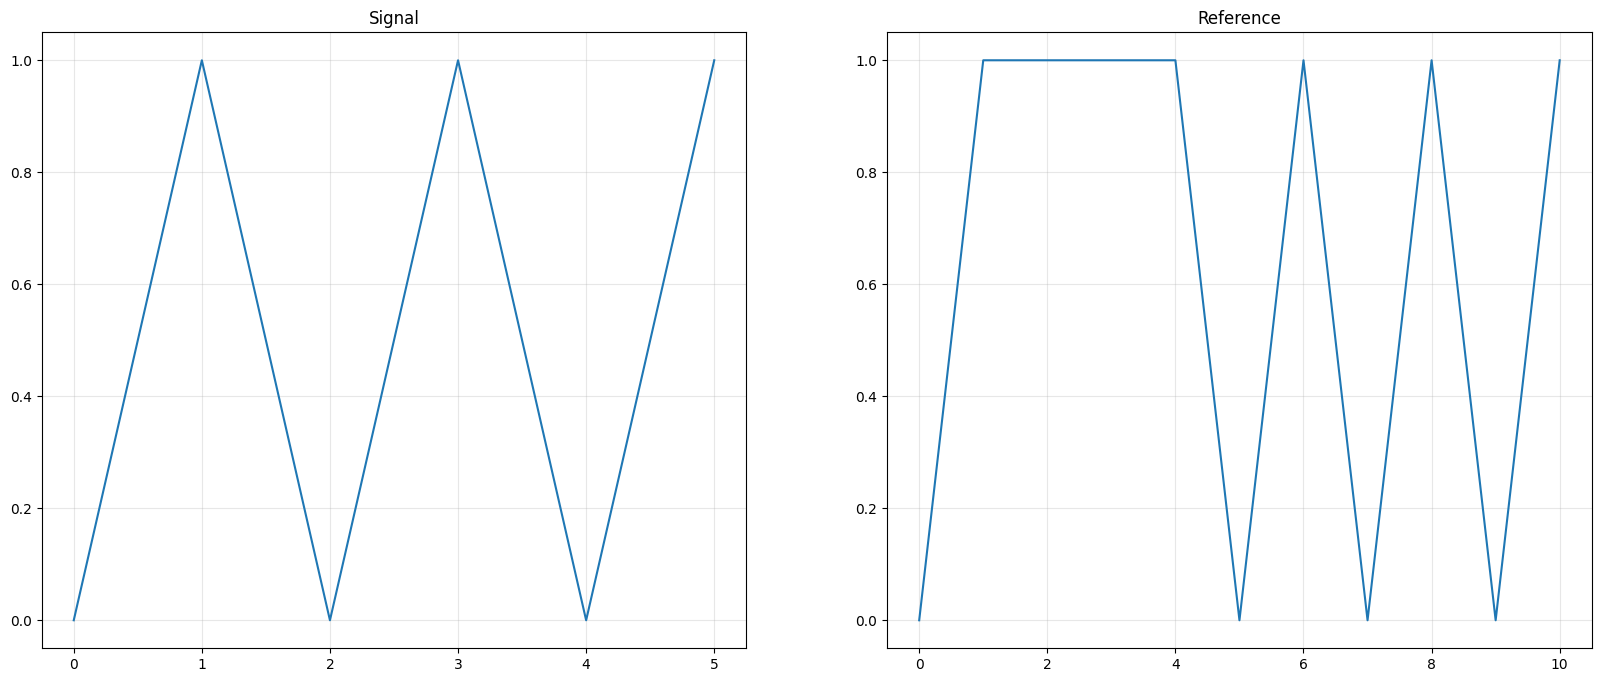

Correlation values:  [ 0.          2.07880452 -4.15760903  4.15760903 -6.23641355  6.23641355]
matched_place:  5


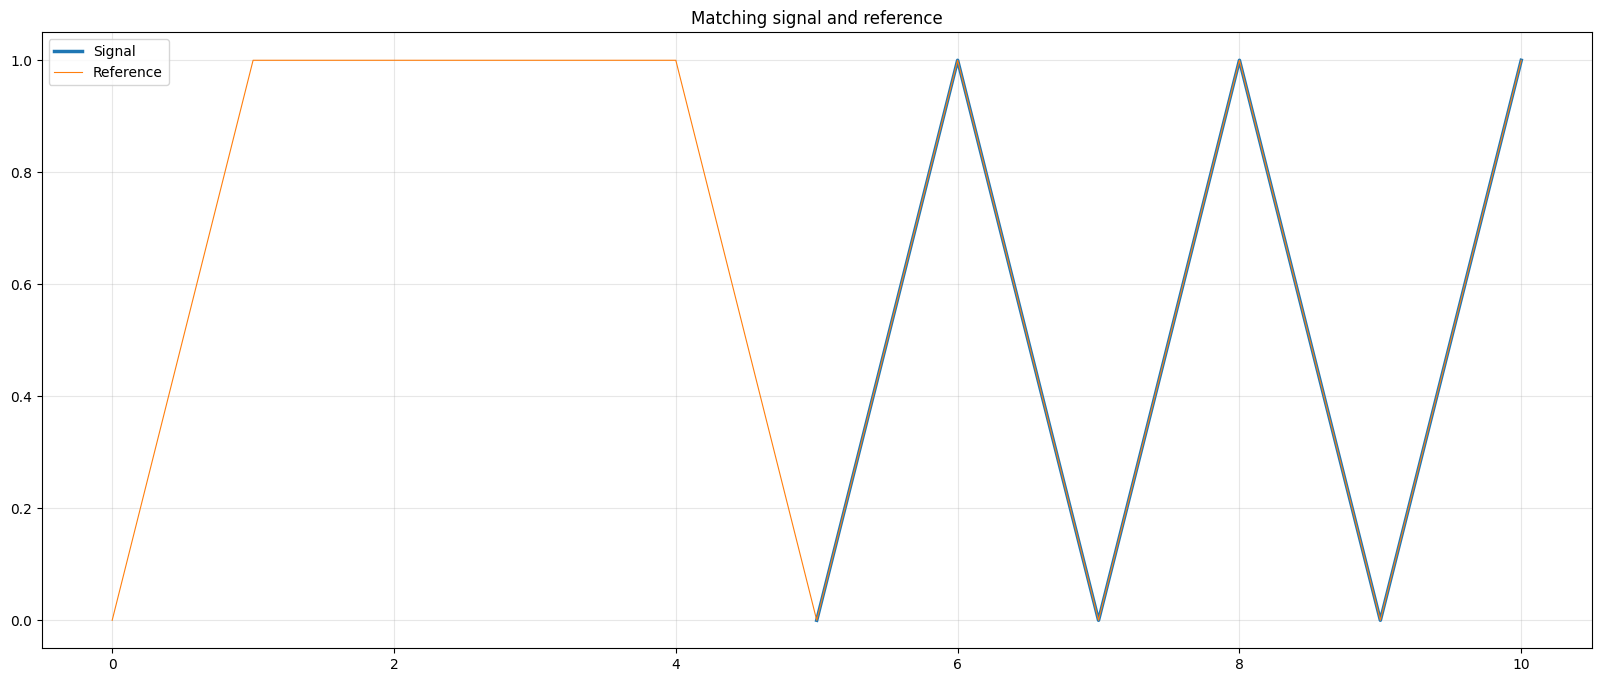

In [25]:
# dummy example to understand scipy.signal.correlate()
signal = np.array([0,1,0,1,0,1], dtype = int)
reference = np.array([0,1,1,1,1,0,1,0,1,0,1], dtype = int) # where we are looking for similar patterns

# plotting the two before matching
plt.figure(figsize = (20,8))
plt.subplot(1,2,1)
plt.plot(signal)
plt.title("Signal")
plt.grid(True, alpha = 0.3)
plt.subplot(1,2,2)
plt.plot(reference)
plt.title("Reference")
plt.grid(True, alpha = 0.3)
plt.show()

n_signal = normalize(signal)
n_reference = normalize(reference)

corr = correlate(n_reference, n_signal, mode = 'valid')
print("Correlation values: ", corr)
matched_place = np.argmax(corr) # where the signal starts matching the reference 
print("matched_place: ", matched_place)


# x axis 
signal_x = np.arange(matched_place, matched_place + len(signal)) # this is for shifting to start from matched place
reference_x = np.arange(len(reference))

# plotting 
plt.figure(figsize= (20,8))
plt.plot(signal_x, signal, linewidth = 2.5, label = 'Signal')
plt.plot(reference_x, reference, linewidth = 0.8, label = 'Reference')
plt.title("Matching signal and reference")
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

### Applying this to the real data.

We'll do the same thing with the actual GR values: use matched_place to find the corresponding index in the typewell, then pull out its TVT and assign it to that row in the horizontal well dataset.


The difference is we won't take the whole array of GR values — we'll slide a small window of GR values at a time, for more precision. Each window produces one matched TVT and one confidence/correlation score, which we'll store in two new columns: matched_tvt and match_score.


Since each window covers several rows but only produces one matched value, we'll assign that value to the center row of the window, rather than to every row it covers — that gives the most representative position for the match. Do not worry about the rest of Matched TVT rows, they will get filled as the window slides :)

In [26]:
# creating a function to process each well datasets separately. 
def process_well(h_df, tw_df):
    # remove nan from GR columns first for cross correlation 
    h_GR_clean = h_df['GR'].interpolate(limit_direction = 'both')
    tw_GR_clean = tw_df['GR'].interpolate(limit_direction= 'both')
    
    norm_h_GR = normalize(h_GR_clean)
    norm_tw_GR = normalize(tw_GR_clean)

    # initialise the new columns in horizontal file 
    # (We use temporary NumPy arrays here for lightning-fast loop writes)
    matched_TVT_arr = np.full(len(norm_h_GR), np.nan)
    matched_score_arr = np.full(len(norm_h_GR), np.nan)
    tw_TVT_arr = tw_df['TVT'].to_numpy() # Converted to array to avoid .iloc slowdown

    # cross-correlation 
    for i in range(0,len(norm_h_GR)- WINDOW):
        h_seq = norm_h_GR[i:i + WINDOW]
        corr = correlate(norm_tw_GR, h_seq, mode = 'valid') 
        matched_place = np.argmax(corr) 
        confidence_score = corr[matched_place] 
        centre = (i + WINDOW ) // 2


        # assign it to columns
        # (Writing to the NumPy arrays instead of using slower .loc and .iloc)
        matched_TVT_arr[centre] = tw_TVT_arr[(matched_place + WINDOW) // 2]
        matched_score_arr[centre] = confidence_score

    # Assign the fast arrays back to the DataFrame columns once the loop is done
    h_df['matched_TVT'] = matched_TVT_arr
    h_df['matched_score'] = matched_score_arr
        
    # add rolling window features 
    #GR 
    h_df['GR_mean'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['GR_std'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()
    # later if we are not sure which rolling window value is the best, we run a loop to add features 
    # with more options (e.g. 10, 20, 100) and let the model decide with feature importance!

    #Z slope 
    h_df['Z_slope'] = h_df['Z'].diff(10) / h_df['MD'].diff(10)
    h_df['Z_slope_mean'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['Z_slope_std'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()

    return h_df

In [27]:
# process and concatenate all wells 
df = []
for h_file in tqdm(HORIZONTAL_FILES):
    well_ID = os.path.basename(h_file).split("__")[0]
    tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    h_df = pd.read_csv(h_file)
    tw_df = pd.read_csv(tw_file)

    # process the data 
    processed_df = process_well(h_df, tw_df)
    df.append(processed_df)

# concatenate everything 
data = pd.concat(df, ignore_index = True)

  0%|          | 0/773 [00:00<?, ?it/s]

In [28]:
data.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,matched_TVT,matched_score,GR_mean,GR_std,Z_slope,Z_slope_mean,Z_slope_std
0,11663.0,2999945.15,1090240.89,-9410.08,-9402.89,-9547.57,-9579.66,-9695.42,-9731.81,-9869.40,11862.35,84.588494,11862.35,NaN,NaN,74.561435,17.670097,NaN,-0.899200,0.001304
1,11664.0,2999944.87,1090241.21,-9410.98,-9403.08,-9547.76,-9579.85,-9695.62,-9732.00,-9869.60,11863.06,99.206886,11863.06,NaN,NaN,74.976221,16.983804,NaN,-0.898833,0.001472
2,11665.0,2999944.59,1090241.53,-9411.89,-9402.88,-9547.56,-9579.65,-9695.41,-9731.80,-9869.39,11864.17,100.421534,11864.17,NaN,NaN,74.976221,16.983804,NaN,-0.898429,0.001718
3,11666.0,2999944.30,1090241.86,-9412.79,-9402.67,-9547.35,-9579.44,-9695.21,-9731.59,-9869.19,11865.28,78.504601,11865.28,NaN,NaN,75.002214,16.317801,NaN,-0.898000,0.002000
4,11667.0,2999944.02,1090242.18,-9413.69,-9402.47,-9547.15,-9579.24,-9695.00,-9731.39,-9868.98,11866.38,58.771903,11866.38,NaN,NaN,75.088671,15.727791,NaN,-0.897556,0.002297


In [29]:
data.shape

(5092255, 20)

# 4. Modeling

# 5. Evaluation